# Détection hors domaine (OOD) par Auto-Encodeur convolutif

Filtre d'anomalie **non supervisé** placé **en amont** du classifieur CNN.
Un auto-encodeur (AE) entraîné uniquement sur les images médicales apprend à les reconstruire.
Une image hors domaine se reconstruit mal → **erreur de reconstruction élevée** = signal d'anomalie.

**Dépendances** : ce notebook réutilise les variables déjà créées dans `Entrainnement_modèle.ipynb` :
`device`, `X_tensor` (images prétraitées (N,3,224,224)), et le classifieur `model`/`le`.
Exécute d'abord les cellules de préparation des données de l'autre notebook, ou recharge `data_preprocess.pkl`.

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score
from PIL import Image
from torchvision import transforms
import pandas as pd

import mlflow

# --- Backend MLflow (SQLite, chemin absolu pour éviter les soucis Windows) ---
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
os.chdir(r"C:\Users\USER\Desktop\Master_2_Data_Science\Deep_learning")
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("ood_detection")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cuda


## 1. Données — entraînement non supervisé sur TOUT le dataset

L'AE est entraîné sans labels, uniquement sur les images du domaine (plaies).

In [34]:
df = pd.read_pickle("Projet\data_preprocess.pkl")
X = np.stack(df["img_preprocess"].values)
if X.shape[-1] == 3: X = np.transpose(X, (0,3,1,2))
X_tensor = torch.tensor(X, dtype=torch.float32)

# Dataset image-only (non supervisé) sur l'ensemble complet
ae_dataset = TensorDataset(X_tensor)
ae_loader  = DataLoader(ae_dataset, batch_size=32, shuffle=True)

print("Images d'entraînement AE :", len(ae_dataset), "| shape :", tuple(X_tensor.shape[1:]))
print("Plage de valeurs :", float(X_tensor.min()), "->", float(X_tensor.max()))

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\USER\AppData\Local\Temp\ipykernel_3628\1228265904.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_pickle("Projet\data_preprocess.pkl")


Images d'entraînement AE : 854 | shape : (3, 224, 224)
Plage de valeurs : -1.0 -> 1.0


## 2. Architecture — Auto-Encodeur convolutif

Encodeur 224→14, goulot d'étranglement, décodeur 14→224. Sortie `Tanh` (données normalisées ~[-1,1]).

In [35]:
class ConvAE(nn.Module):
    def __init__(self, latent_ch=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  nn.ReLU(True),   # 224 -> 112
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(True),   # 112 -> 56
            nn.Conv2d(64, 128, 4, 2, 1),nn.ReLU(True),   # 56  -> 28
            nn.Conv2d(128, latent_ch, 4, 2, 1), nn.ReLU(True),  # 28 -> 14
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_ch, 128, 4, 2, 1), nn.ReLU(True),  # 14 -> 28
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(True),         # 28 -> 56
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  nn.ReLU(True),         # 56 -> 112
            nn.ConvTranspose2d(32, 3, 4, 2, 1),   nn.Tanh(),             # 112 -> 224
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

## 3. Entraînement + logging MLflow

In [36]:
EPOCHS = 20
LR = 1e-3

ae = ConvAE().to(device)
optimizer = optim.Adam(ae.parameters(), lr=LR)
criterion = nn.MSELoss()

with mlflow.start_run(run_name="conv_autoencoder"):
    mlflow.log_params({"architecture":"ConvAE","epochs":EPOCHS,"lr":LR,
                       "batch_size":ae_loader.batch_size,"loss":"MSE","latent_ch":128})

    for epoch in range(EPOCHS):
        ae.train(); running = 0.0
        for (imgs,) in ae_loader:
            imgs = imgs.to(device)
            optimizer.zero_grad()
            loss = criterion(ae(imgs), imgs)
            loss.backward(); optimizer.step()
            running += loss.item() * imgs.size(0)
        epoch_loss = running / len(ae_dataset)
        mlflow.log_metric("recon_loss", epoch_loss, step=epoch)
        print(f"epoch {epoch+1:02d}/{EPOCHS} | recon_loss={epoch_loss:.5f}")

    mlflow.pytorch.log_model(ae, artifact_path="autoencoder", serialization_format="pickle")
    print("AE entraîné et loggé dans MLflow.")

epoch 01/20 | recon_loss=0.15346
epoch 02/20 | recon_loss=0.05649
epoch 03/20 | recon_loss=0.04513
epoch 04/20 | recon_loss=0.03797
epoch 05/20 | recon_loss=0.03245
epoch 06/20 | recon_loss=0.02433
epoch 07/20 | recon_loss=0.01775
epoch 08/20 | recon_loss=0.01522
epoch 09/20 | recon_loss=0.01412
epoch 10/20 | recon_loss=0.01326
epoch 11/20 | recon_loss=0.01240
epoch 12/20 | recon_loss=0.01253
epoch 13/20 | recon_loss=0.01124
epoch 14/20 | recon_loss=0.01072
epoch 15/20 | recon_loss=0.01075
epoch 16/20 | recon_loss=0.01024
epoch 17/20 | recon_loss=0.00955
epoch 18/20 | recon_loss=0.00934
epoch 19/20 | recon_loss=0.00891


2026/06/30 15:42:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/30 15:42:49 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/30 15:42:49 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


epoch 20/20 | recon_loss=0.00907


2026/06/30 15:43:00 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.20.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torchvision==0.20.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


AE entraîné et loggé dans MLflow.


## 4. Calibration du seuil OOD

**Stratégie : percentile sur le jeu d'entraînement.** On calcule l'erreur de reconstruction de toutes les images in-domain, et on fixe le seuil au **95e percentile** : on accepte de rejeter ~5 % d'images connues (faux positifs) pour mieux capter l'inconnu.

Seuil OOD (p95) = 0.01982
Erreur in-domain : moy=0.00879, max=0.07524


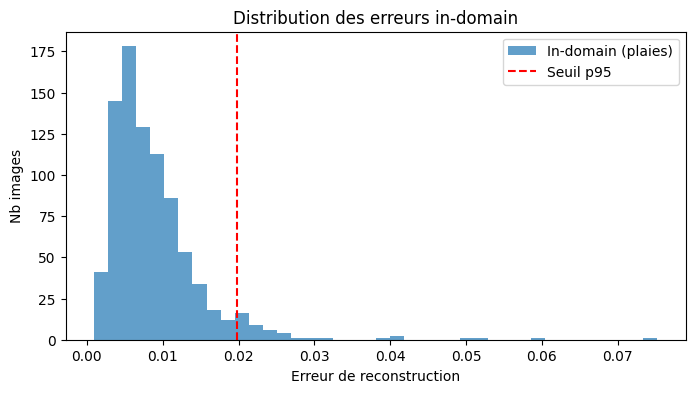

In [37]:
@torch.no_grad()
def reconstruction_error(model, x):
    """Erreur MSE par image -> score d'anomalie. x : (N,3,224,224)."""
    model.eval()
    x = x.to(device)
    recon = model(x)
    return ((recon - x) ** 2).mean(dim=[1, 2, 3]).cpu().numpy()

# Scores sur tout l'in-domain
scores_in = []
eval_loader = DataLoader(ae_dataset, batch_size=32, shuffle=False)
for (imgs,) in eval_loader:
    scores_in.append(reconstruction_error(ae, imgs))
scores_in = np.concatenate(scores_in)

PERCENTILE = 95
THRESHOLD = np.percentile(scores_in, PERCENTILE)
print(f"Seuil OOD (p{PERCENTILE}) = {THRESHOLD:.5f}")
print(f"Erreur in-domain : moy={scores_in.mean():.5f}, max={scores_in.max():.5f}")

plt.figure(figsize=(8,4))
plt.hist(scores_in, bins=40, alpha=0.7, label="In-domain (plaies)")
plt.axvline(THRESHOLD, color="red", ls="--", label=f"Seuil p{PERCENTILE}")
plt.xlabel("Erreur de reconstruction"); plt.ylabel("Nb images")
plt.title("Distribution des erreurs in-domain"); plt.legend(); plt.show()

## 5. Test avec des images hors domaine

Charge des photos non médicales (paysage, objet, animal…) pour vérifier qu'elles dépassent le seuil.

In [39]:
ood_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),  # même normalisation que l'entraînement
])

def load_external(path):
    img = Image.open(path).convert("RGB")
    return ood_transforms(img).unsqueeze(0)  # (1,3,224,224)

ood_paths = [
    "Projet\Image_test\paysage.jpg",
    "Projet\Image_test\car.jpg",
]

for p in ood_paths:
    x = load_external(p)
    err = reconstruction_error(ae, x)[0]
    verdict = "OOD (rejetée)" if err > THRESHOLD else "in-domain (acceptée)"
    print(f"{os.path.basename(p):30s} | erreur={err:.5f} | {verdict}")

<>:12: SyntaxWarning: invalid escape sequence '\I'
<>:13: SyntaxWarning: invalid escape sequence '\I'
<>:12: SyntaxWarning: invalid escape sequence '\I'
<>:13: SyntaxWarning: invalid escape sequence '\I'
C:\Users\USER\AppData\Local\Temp\ipykernel_3628\2508126843.py:12: SyntaxWarning: invalid escape sequence '\I'
  "Projet\Image_test\paysage.jpg",
C:\Users\USER\AppData\Local\Temp\ipykernel_3628\2508126843.py:13: SyntaxWarning: invalid escape sequence '\I'
  "Projet\Image_test\car.jpg",


paysage.jpg                    | erreur=0.08073 | OOD (rejetée)
car.jpg                        | erreur=0.04991 | OOD (rejetée)


## 6. Intégration dans le pipeline

Le filtre OOD passe **avant** le classifieur. Si l'erreur dépasse le seuil → alerte, on ne classe pas.

In [41]:
from sklearn.preprocessing import LabelEncoder
from torchvision import models
model = torch.load("Projet\saved_models\Resnet_weights.pth")
le = LabelEncoder()
y = le.fit_transform(df['Class']) 

def pipeline_inference(x, ae, classifier, threshold, label_encoder=None):
    err = reconstruction_error(ae, x)[0]
    if err > threshold:
        return {"status": "ALERTE_OOD",
                "message": "Image hors domaine — non classifiée",
                "anomaly_score": float(err), "threshold": float(threshold)}

    # In-domain -> classification
    classifier.eval()
    with torch.no_grad():
        out = classifier(x.to(device))
        idx = int(torch.argmax(out, dim=1).cpu())
    label = label_encoder.inverse_transform([idx])[0] if label_encoder is not None else idx
    return {"status": "OK", "prediction": label,
            "anomaly_score": float(err), "threshold": float(threshold)}


classifier = models.resnet50(pretrained=False)
classifier.fc = torch.nn.Linear(classifier.fc.in_features, 7)
classifier.load_state_dict(model)  # Charger tes poids sauvegardés
classifier = classifier.to(device)

x = X_tensor[0:1]
print(pipeline_inference(x, ae, classifier, THRESHOLD, le))

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\USER\AppData\Local\Temp\ipykernel_3628\1119230576.py:3: SyntaxWarning: invalid escape sequence '\s'
  model = torch.load("Projet\saved_models\Resnet_weights.pth")
C:\Users\USER\AppData\Local\Temp\ipykernel_3628\1119230576.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`

{'status': 'OK', 'prediction': 'Abrasions', 'anomaly_score': 0.005159963853657246, 'threshold': 0.019824007526040077}


## Réponses au rapport

**Pourquoi un CNN classifieur seul ne suffit-il pas à détecter le hors domaine ?**

Un classifieur est entraîné en *monde fermé* : sa dernière couche softmax **répartit forcément la probabilité sur les classes connues** et somme à 1. Confronté à une entrée totalement étrangère, il n'a aucune option « aucune des classes » — il produit malgré tout une distribution, souvent piquée. Le réseau extrapole au-delà de la zone qu'il a apprise, et le softmax mesure une confiance *relative entre classes connues*, pas la *vraisemblance* de l'entrée.

*Exemple concret* : on photographie une **voiture** et on la présente au classifieur de plaies. Si ses formes/couleurs activent surtout les filtres associés à « Burns », le réseau peut sortir `Burns` à **97 % de confiance** — un score élevé et trompeur, alors que l'image n'a rien de médical. Le softmax élevé ne reflète que la classe connue la plus proche, jamais le fait que l'image est hors distribution. L'AE, lui, échoue à la reconstruire (erreur élevée) et la rejette correctement.

**Comment le seuil a-t-il été choisi, et quel compromis FP/FN ?**

Le seuil est fixé au **95e percentile** des erreurs de reconstruction sur le jeu d'entraînement : par construction, ~5 % des images connues seront au-dessus du seuil. C'est une stratégie non supervisée qui ne nécessite aucune image OOD pour être calibrée. Quand des exemples OOD étiquetés sont disponibles, on raffine via la **courbe ROC** (ex. indice de Youden TPR−FPR) ou la **courbe PR**.

Le compromis est direct :
- **Seuil bas** → on détecte presque tout l'inconnu (peu de **faux négatifs** : images OOD passées inaperçues), mais on rejette beaucoup d'images valides (**faux positifs** : plaies réelles bloquées avant classification).
- **Seuil haut** → on laisse passer toutes les images médicales (peu de FP), mais on rate les cas OOD ambigus (FN).

Dans un contexte médical, **un faux négatif OOD est plus dangereux** : une image non pertinente classée à tort comme une plaie peut induire une décision erronée. On privilégie donc un seuil plutôt **conservateur (bas)**, quitte à demander une nouvelle prise de vue pour quelques images connues rejetées — coût opérationnel acceptable au regard du risque clinique.